In [33]:
import numpy as np
import pandas as pd
import h5py
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torchinfo import summary
import torch.utils.checkpoint as checkpoint
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm, trange
import seaborn as sns
import gc
import time
import warnings
from collections import deque
import psutil
import os

In [35]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [44]:
FILE_PATH = '/mnt/sda3/dataset_AMC /radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5'
JSON_PATH = '/mnt/sda3/dataset_AMC /radioml2018/versions/2/classes-fixed.json'

TARGET_MODULATIONS = [
    'OOK','BPSK', 'QPSK', '8PSK','16QAM','GMSK' #,'AM-SSB-WC'
]

BATCH_SIZE = 64 # adjust to my laptop 
#LEARNING_RATE = 0.003 
NUM_EPOCHS = 100 
NUM_WORKERS = 0 #Temporary check it  

INPUT_CHANNELS = 2 
SEQUENCE_LENGTH = 1024 
NUM_CLASSES = 6 # adjust this to 

# TRAIN_RATIO = 0.7 
# VALID_RATIO = 0.2 
# TEST_RATIO = 0.1 

nf_train = int(BATCH_SIZE * 0.7)
nf_valid = int(BATCH_SIZE * 0.2)
nf_test  = BATCH_SIZE - nf_train - nf_valid

print("📋 Training Parameters:")
print(f"  Batch size: {BATCH_SIZE}")
#print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")

📋 Training Parameters:
  Batch size: 64
  Epochs: 100


In [45]:
def dataset_split(data,
                  modulations_classes,
                  modulations,
                  snrs,
                  target_modulations,
                  mode,
                  target_snrs,
                  train_proportion=0.8, # training 70 %
                  valid_proportion=0.2, # validation 20 %
                  test_proportion=0.0, # testing 10 % 
                  seed=48):
    np.random.seed(seed)
    X_output = []
    Y_output = []
    Z_output = []                                   

    target_modulation_indices = [modulations_classes.index(modu) for modu in target_modulations]

    for modu in target_modulation_indices:
        for snr in target_snrs:
            snr_modu_indices = np.where((modulations == modu) & (snrs == snr))[0]

            np.random.shuffle(snr_modu_indices)
            num_samples = len(snr_modu_indices)
            train_end = int(train_proportion * num_samples)
            valid_end = int((train_proportion + valid_proportion) * num_samples)

            if mode == 'train':
                indices = snr_modu_indices[:train_end]
            elif mode == 'valid':
                indices = snr_modu_indices[train_end:valid_end]
            elif mode == 'test':
                indices = snr_modu_indices[valid_end:]
            else:
                raise ValueError(f'unknown mode: {mode}. Valid modes are train, valid and test')

            X_output.append(data[np.sort(indices)])
            Y_output.append(modulations[np.sort(indices)])
            Z_output.append(snrs[np.sort(indices)])

    X_array = np.vstack(X_output)
    Y_array = np.concatenate(Y_output)
    Z_array = np.concatenate(Z_output)
    for index, value in enumerate(np.unique(np.copy(Y_array))):
        Y_array[Y_array == value] = index
    return X_array, Y_array, Z_array

In [46]:
class RadioML18Dataset(Dataset):
    def __init__(self, mode: str,use_fft: bool = False, seed=48,):
        super(RadioML18Dataset, self).__init__()

        self.file_path = FILE_PATH 
        self.json_path = JSON_PATH 
        self.target_modulations = TARGET_MODULATIONS
        self.use_fft = use_fft 
        try:
            hdf5_file = h5py.File(self.file_path, 'r') #Escaped backslashes 
            self.modulation_classes = json.load(open(self.json_path, 'r'))
        except Exception as e: 
            print(f"Error loading file : {e}")
            raise e 
        
        self.X = hdf5_file['X']
        self.Y = np.argmax(hdf5_file['Y'], axis=1)
        self.Z = hdf5_file['Z'][:, 0]

        train_proportion=(6*26*nf_train)/self.X.shape[0]
        valid_proportion=(6*26*nf_valid)/self.X.shape[0]
        test_proportion=(6*26*nf_test)/self.X.shape[0]

        self.target_snrs = np.unique(self.Z)

        self.X_data, self.Y_data, self.Z_data = dataset_split(
                                                                  data = self.X,
                                                                  modulations_classes = self.modulation_classes,
                                                                  modulations = self.Y,
                                                                  snrs = self.Z,
                                                                  mode = mode,
                                                                  train_proportion = train_proportion,
                                                                  valid_proportion = valid_proportion,
                                                                  test_proportion = test_proportion,
                                                                  target_modulations = self.target_modulations,
                                                                  target_snrs  = self.target_snrs,
                                                                  seed=48
                                                                 )

        # *** CRITICAL FIX: Apply I/Q swap correction for AMC compatibility ***
        print(f"🔧 Applying I/Q swap fix to {mode} dataset...")
 
        self.X_data = self.X_data[:,:,[1,0]]
        print(f"✅ I/Q channels corrected for real-world compatibility")
        if self.use_fft:
            print("Dataset configured to use FFT as input")

        # store statistic of whole dataset (unchanged)
        self.num_data = self.X_data.shape[0]
        self.num_lbl = len(self.target_modulations)
        self.num_snr = self.target_snrs.shape[0]

    def __len__(self):
        return self.X_data.shape[0]

    def __getitem__(self, idx):
        x_raw,y,z = self.X_data[idx], self.Y_data[idx], self.Z_data[idx]
        
        # convert to tensor adn transpose to (channels and sequence length)
        x = torch.from_numpy(x_raw).float().transpose(0,1)

        if self.use_fft: 
            complex_signal = torch.complex(x[0],x[1])
            fft_result = torch.fft.fft(complex_signal)

            fft_real = torch.real(fft_result)
            fft_imag = torch.imag(fft_result)

            x = torch.stack([fft_real,fft_imag], dim = 0)
        
        return x,y,z

In [47]:
try:
    from BaseCNN import create_BaseCNN_NET

    # Match the real signature: (n_labels, dropout_rate)
    model = create_BaseCNN_NET(n_labels=NUM_CLASSES, dropout_rate=0.5).to(device)
    print("✅ Successfully built BaseCNN:", model)

except Exception as e:
    print(f"⚠️ Could not build BaseCNN: {e}")

✅ Successfully built BaseCNN: BaseCNN_NET(
  (backbone): Sequential(
    (0): BaseCNN_Block(
      (block): Sequential(
        (0): Conv1d(2, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(32, 32, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.2, inplace=False)
      )
    )
    (1): BaseCNN_Block(
      (block): Sequential(
        (0): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): Batch

/tmp/ipykernel_67367/4238788705.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Loading datasets...
🔧 Applying I/Q swap fix to train dataset...
✅ I/Q channels corrected for real-world compatibility
Datasets loaded successfully.
Total dataset size: 1716
Train dataset size: 1372 (80%)
Validation dataset size: 344 (20%)
🚀 Starting Training...
Epoch  Train Loss   Train Acc   Valid Loss   Valid Acc   Time     Status
  Training: 45%

/tmp/ipykernel_67367/4238788705.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


1      0.7806       68.00       0.7725       67.44       0.3     s 💾 BEST
2      0.7309       69.46       0.7866       65.70       0.3     s ⏳ 1/10
3      0.7311       70.41       0.7574       66.57       0.3     s ⏳ 2/10
4      0.7685       68.08       0.7514       65.99       0.3     s ⏳ 3/10
5      0.7270       68.29       0.7511       66.28       0.3     s ⏳ 4/10
6      0.7551       68.44       0.7892       67.44       0.3     s ⏳ 5/10
7      0.7396       69.75       0.7700       64.83       0.3     s ⏳ 6/10
8      0.7341       68.66       0.7466       67.15       0.3     s ⏳ 7/10
9      0.7389       69.17       0.7568       66.28       0.3     s ⏳ 8/10
10     0.7370       69.39       0.7400       65.70       0.3     s ⏳ 9/10
11     0.7499       68.88       0.7457       67.73       0.3     s 💾 BEST
12     0.7040       70.34       0.7617       67.44       0.3     s ⏳ 1/10
13     0.7207       70.04       0.7421       68.60       0.3     s 💾 BEST
14     0.7090       70.12       0.7568

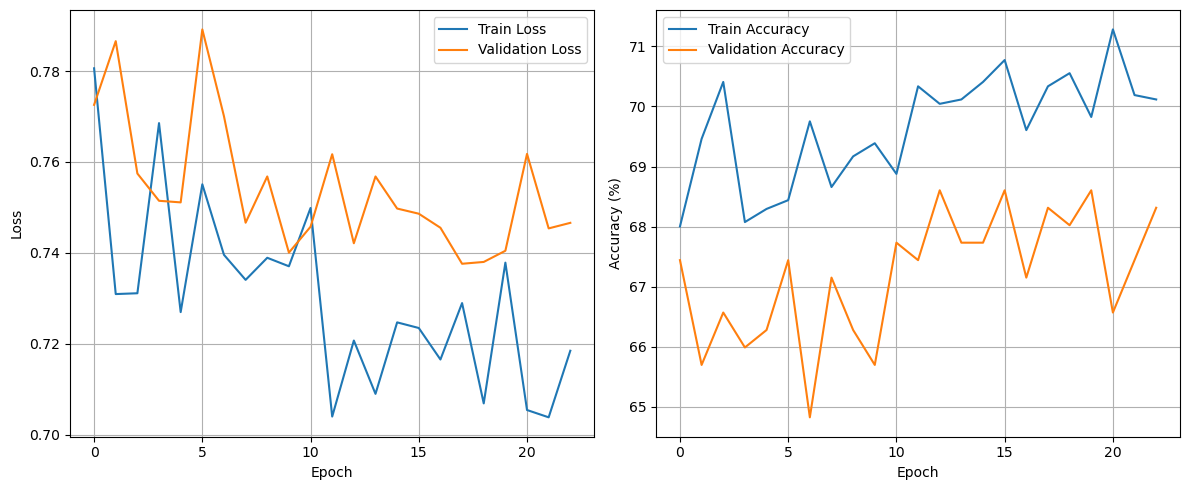

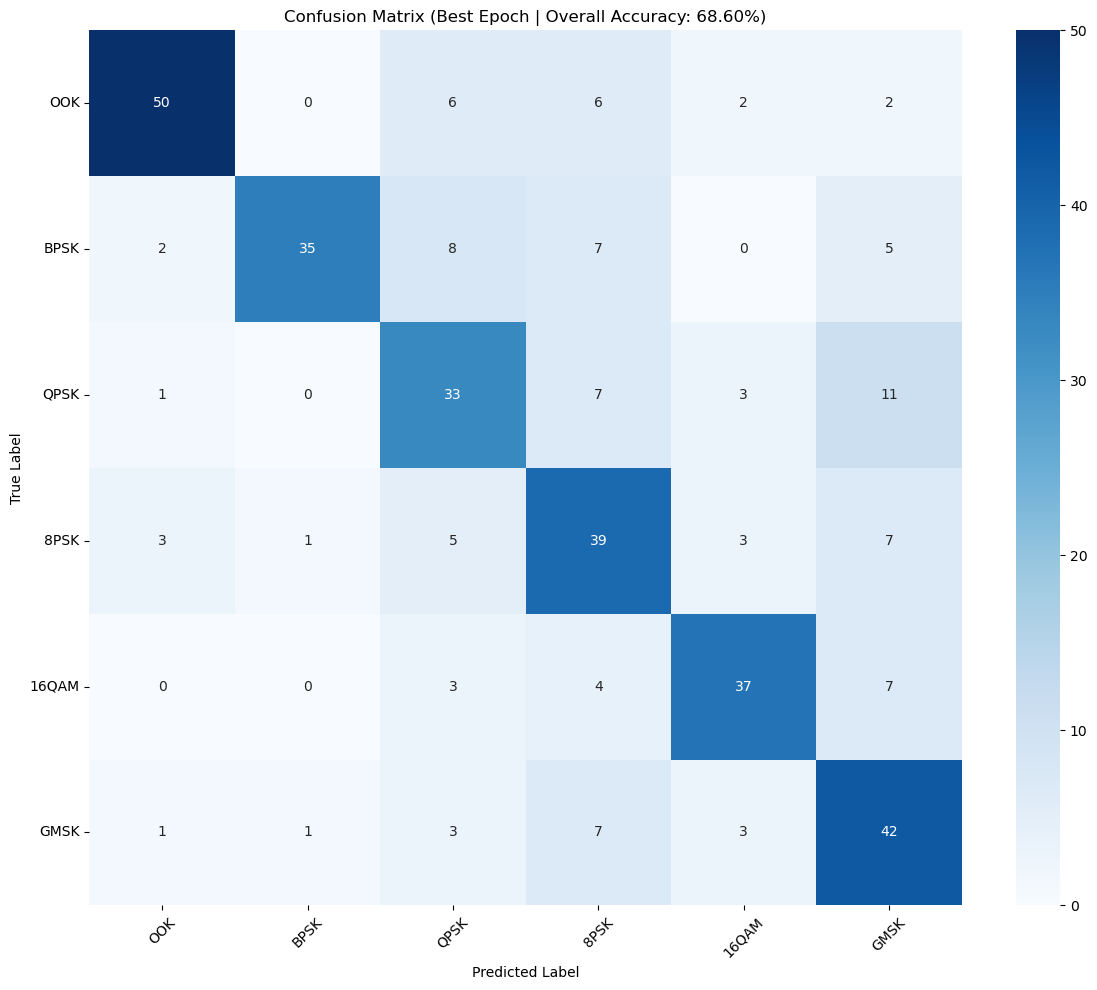

In [50]:
# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    patience=7, 
    factor=0.5,
    verbose=True
)

scaler = GradScaler()

# --- Data Loaders ---
print("\nLoading datasets...")
full_dataset = RadioML18Dataset('train', use_fft=False)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
valid_size = dataset_size - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print("Datasets loaded successfully.")
print(f"Total dataset size: {dataset_size}")
print(f"Train dataset size: {len(train_dataset)} (80%)")
print(f"Validation dataset size: {len(valid_dataset)} (20%)")

# --- Training and Validation Loop ---
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
best_accuracy = 0.0
patience_counter = 0
patience = 10
BEST_MODEL_PATH = 'best_cnn_model2.pth'

# Store predictions/labels for confusion matrix
final_predictions = []
final_true_labels = []

print("🚀 Starting Training...")
print("=" * 80)
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<11} {'Valid Loss':<12} {'Valid Acc':<11} {'Time':<8} {'Status'}")
print("=" * 80)

start_time = time.time()  # Track total training time

for epoch in range(NUM_EPOCHS):  # Ensure 'epochs' is defined
    epoch_start = time.time()
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_idx, (inputs, labels, _) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % (len(train_loader) // 4) == 0 and batch_idx > 0:
            progress = (batch_idx / len(train_loader)) * 100
            print(f"\r  Training: {progress:.0f}%", end='', flush=True)
    
    # Validation Phase  
    model.eval()
    valid_loss, valid_correct, valid_total = 0.0, 0, 0
    epoch_predictions = []  # Store current epoch predictions
    epoch_labels = []       # Store current epoch labels
    
    with torch.no_grad():
        for inputs, labels, _ in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()
            
            # Collect for confusion matrix
            epoch_predictions.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_valid_loss = valid_loss / len(valid_loader.dataset)
    epoch_train_acc = 100. * train_correct / train_total
    epoch_valid_acc = 100. * valid_correct / valid_total
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    valid_losses.append(epoch_valid_loss)
    train_accuracies.append(epoch_train_acc)
    valid_accuracies.append(epoch_valid_acc)
    
    # Learning rate scheduling
    scheduler.step(epoch_valid_acc)
    
    # Early stopping check
    if epoch_valid_acc > best_accuracy:
        best_accuracy = epoch_valid_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        # Save best epoch predictions/labels
        final_predictions = epoch_predictions
        final_true_labels = epoch_labels
        status = "💾 BEST"
    else:
        patience_counter += 1
        if patience_counter >= patience:
            status = "⏹️ STOP"
        else:
            status = f"⏳ {patience_counter}/{patience}"
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    
    # Print epoch summary
    print(f"\r{epoch+1:<6} {epoch_train_loss:<12.4f} {epoch_train_acc:<11.2f} {epoch_valid_loss:<12.4f} {epoch_valid_acc:<11.2f} {epoch_time:<8.1f}s {status}")
    
    # Early stopping
    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_time
print("=" * 80)
print(f"✅ Training Complete! Best Accuracy: {best_accuracy:.2f}% | Total Time: {total_time/60:.1f} min")

# --- Plot Training Curves ---
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- Confusion Matrix ---
# Ensure TARGET_MODULATIONS is defined (list of class names)
if len(final_predictions) > 0 and len(final_true_labels) > 0:
    cm = confusion_matrix(final_true_labels, final_predictions)
    accuracy = 100. * np.diag(cm).sum() / cm.sum()

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=TARGET_MODULATIONS, 
                yticklabels=TARGET_MODULATIONS)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix (Best Epoch | Overall Accuracy: {accuracy:.2f}%)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    plt.show()
else:
    print("Warning: No predictions available for confusion matrix")
    

/tmp/ipykernel_67367/3397036996.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Loading datasets...
🔧 Applying I/Q swap fix to train dataset...
✅ I/Q channels corrected for real-world compatibility
Dataset configured to use FFT as input
Datasets loaded successfully.
Total dataset size: 1716
Train dataset size: 1372 (80%)
Validation dataset size: 344 (20%)
🚀 Starting Training...
Epoch  Train Loss   Train Acc   Valid Loss   Valid Acc   Time     Status
  Training: 45%

/tmp/ipykernel_67367/3397036996.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


1      3.6843       20.04       1.7958       24.13       0.4     s 💾 BEST
2      1.8325       22.67       1.5665       28.49       0.3     s 💾 BEST
3      1.5871       26.75       1.5504       29.07       0.3     s 💾 BEST
4      1.5706       28.57       1.5295       31.69       0.3     s 💾 BEST
5      1.5614       28.43       1.5390       29.94       0.3     s ⏳ 1/10
6      1.5595       29.66       1.5133       29.65       0.3     s ⏳ 2/10
7      1.5407       28.72       1.5117       30.52       0.3     s ⏳ 3/10
8      1.5425       28.21       1.5139       30.52       0.3     s ⏳ 4/10
9      1.5349       27.55       1.4971       29.07       0.3     s ⏳ 5/10
10     1.5286       28.72       1.4996       31.10       0.3     s ⏳ 6/10
11     1.5220       28.06       1.5011       29.36       0.3     s ⏳ 7/10
12     1.5143       29.30       1.4869       30.52       0.3     s ⏳ 8/10
13     1.5004       31.20       1.4887       26.74       0.3     s ⏳ 9/10
14     1.5064       29.88       1.4905

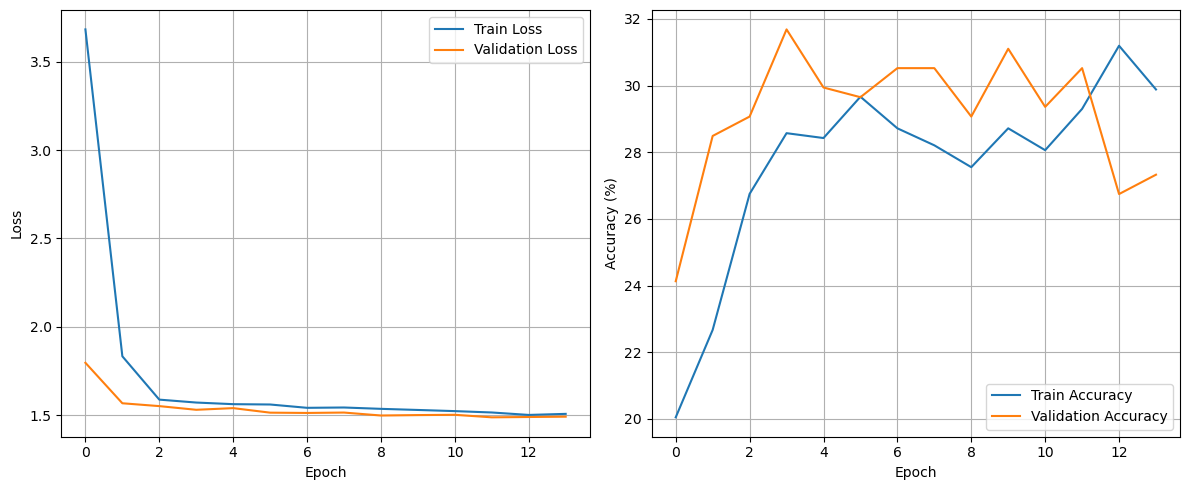

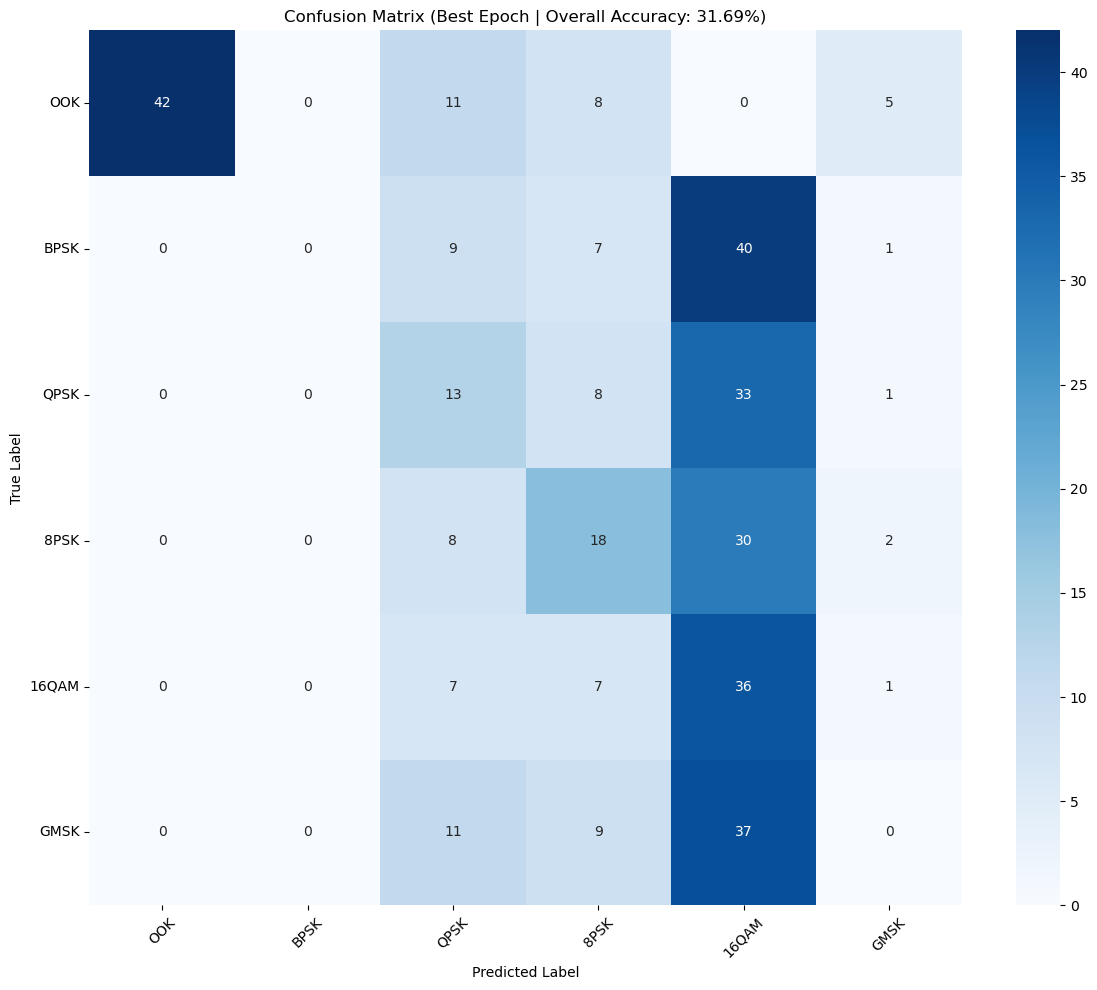

In [51]:
# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    patience=7, 
    factor=0.5,
    verbose=True
)

scaler = GradScaler()

# --- Data Loaders ---
print("\nLoading datasets...")
full_dataset = RadioML18Dataset('train', use_fft=True)
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
valid_size = dataset_size - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print("Datasets loaded successfully.")
print(f"Total dataset size: {dataset_size}")
print(f"Train dataset size: {len(train_dataset)} (80%)")
print(f"Validation dataset size: {len(valid_dataset)} (20%)")

# --- Training and Validation Loop ---
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
best_accuracy = 0.0
patience_counter = 0
patience = 10
BEST_MODEL_PATH = 'best_cnn_model2.pth'

# Store predictions/labels for confusion matrix
final_predictions = []
final_true_labels = []

print("🚀 Starting Training...")
print("=" * 80)
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<11} {'Valid Loss':<12} {'Valid Acc':<11} {'Time':<8} {'Status'}")
print("=" * 80)

start_time = time.time()  # Track total training time

for epoch in range(NUM_EPOCHS):  # Ensure 'epochs' is defined
    epoch_start = time.time()
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_idx, (inputs, labels, _) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % (len(train_loader) // 4) == 0 and batch_idx > 0:
            progress = (batch_idx / len(train_loader)) * 100
            print(f"\r  Training: {progress:.0f}%", end='', flush=True)
    
    # Validation Phase  
    model.eval()
    valid_loss, valid_correct, valid_total = 0.0, 0, 0
    epoch_predictions = []  # Store current epoch predictions
    epoch_labels = []       # Store current epoch labels
    
    with torch.no_grad():
        for inputs, labels, _ in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()
            
            # Collect for confusion matrix
            epoch_predictions.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_valid_loss = valid_loss / len(valid_loader.dataset)
    epoch_train_acc = 100. * train_correct / train_total
    epoch_valid_acc = 100. * valid_correct / valid_total
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    valid_losses.append(epoch_valid_loss)
    train_accuracies.append(epoch_train_acc)
    valid_accuracies.append(epoch_valid_acc)
    
    # Learning rate scheduling
    scheduler.step(epoch_valid_acc)
    
    # Early stopping check
    if epoch_valid_acc > best_accuracy:
        best_accuracy = epoch_valid_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        # Save best epoch predictions/labels
        final_predictions = epoch_predictions
        final_true_labels = epoch_labels
        status = "💾 BEST"
    else:
        patience_counter += 1
        if patience_counter >= patience:
            status = "⏹️ STOP"
        else:
            status = f"⏳ {patience_counter}/{patience}"
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    
    # Print epoch summary
    print(f"\r{epoch+1:<6} {epoch_train_loss:<12.4f} {epoch_train_acc:<11.2f} {epoch_valid_loss:<12.4f} {epoch_valid_acc:<11.2f} {epoch_time:<8.1f}s {status}")
    
    # Early stopping
    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_time
print("=" * 80)
print(f"✅ Training Complete! Best Accuracy: {best_accuracy:.2f}% | Total Time: {total_time/60:.1f} min")

# --- Plot Training Curves ---
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- Confusion Matrix ---
# Ensure TARGET_MODULATIONS is defined (list of class names)
if len(final_predictions) > 0 and len(final_true_labels) > 0:
    cm = confusion_matrix(final_true_labels, final_predictions)
    accuracy = 100. * np.diag(cm).sum() / cm.sum()

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=TARGET_MODULATIONS, 
                yticklabels=TARGET_MODULATIONS)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix (Best Epoch | Overall Accuracy: {accuracy:.2f}%)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    plt.show()
else:
    print("Warning: No predictions available for confusion matrix")
    

In [52]:
class SignalAugmentation:
    """
    Comprehensive augmentation suite for I/Q signal processing
    Specifically designed for modulation classification
    """
    
    def __init__(self, config=None):
        # Default augmentation configuration
        self.config = config or {
            'noise_std_range': (0.01, 0.05),            # AWGN noise
            'snr_range': (-10, 30),                     # SNR variation
            'phase_shift_range': (-np.pi, np.pi),       # Phase rotation
            'amplitude_scale_range': (0.7, 1.3),        # Amplitude scaling
            'frequency_shift_range': (-0.1, 0.1),       # Frequency offset
            'time_shift_range': (-50, 50),              # Time shifting
            'iq_imbalance_range': (0.9, 1.1),           # I/Q imbalance
            'dc_offset_range': (-0.1, 0.1),             # DC offset
            'multipath_delay_range': (1, 10),           # Multipath fading
            'dropout_prob_range': (0.0, 0.02),          # Sample dropout
        }
    
    def add_awgn_noise(self, signal, probability=0.8):
        """Add Additive White Gaussian Noise"""
        if torch.rand(1).item() < probability:
            std_min, std_max = self.config['noise_std_range']
            noise_std = torch.empty(1).uniform_(std_min, std_max).item()
            
            # Add complex noise to both I and Q channels
            noise = torch.randn_like(signal) * noise_std
            return signal + noise
        return signal
    
    def snr_variation(self, signal, probability=0.6):
        """Simulate different SNR conditions"""
        if torch.rand(1).item() < probability:
            snr_min, snr_max = self.config['snr_range']
            target_snr_db = torch.empty(1).uniform_(snr_min, snr_max).item()
            
            # Calculate current signal power
            signal_power = torch.mean(signal ** 2)
            
            # Calculate required noise power for target SNR
            snr_linear = 10 ** (target_snr_db / 10)
            noise_power = signal_power / snr_linear
            
            # Add noise
            noise = torch.randn_like(signal) * torch.sqrt(noise_power)
            return signal + noise
        return signal
    
    def phase_rotation(self, signal, probability=0.7):
        """Apply random phase rotation (common in RF systems)"""
        if torch.rand(1).item() < probability and signal.size(0) == 2:
            phase_min, phase_max = self.config['phase_shift_range']
            phase_shift = torch.empty(1).uniform_(phase_min, phase_max).item()
            
            # Apply rotation matrix to I/Q
            cos_phi = np.cos(phase_shift)
            sin_phi = np.sin(phase_shift)
            
            i_rotated = signal[0] * cos_phi - signal[1] * sin_phi
            q_rotated = signal[0] * sin_phi + signal[1] * cos_phi
            
            return torch.stack([i_rotated, q_rotated], dim=0)
        return signal
    
    def amplitude_scaling(self, signal, probability=0.6):
        """Apply random amplitude scaling (AGC effects)"""
        if torch.rand(1).item() < probability:
            scale_min, scale_max = self.config['amplitude_scale_range']
            scale_factor = torch.empty(1).uniform_(scale_min, scale_max).item()
            return signal * scale_factor
        return signal
    
    def frequency_offset(self, signal, probability=0.5):
        """Simulate carrier frequency offset"""
        if torch.rand(1).item() < probability and signal.size(0) == 2:
            freq_min, freq_max = self.config['frequency_shift_range']
            freq_offset = torch.empty(1).uniform_(freq_min, freq_max).item()
            
            # Create time vector
            seq_len = signal.size(1)
            t = torch.arange(seq_len, dtype=torch.float32) / seq_len
            
            # Apply frequency offset
            complex_offset = torch.exp(1j * 2 * np.pi * freq_offset * t)
            
            # Convert to I/Q and apply
            cos_offset = torch.real(complex_offset)
            sin_offset = torch.imag(complex_offset)
            
            i_shifted = signal[0] * cos_offset - signal[1] * sin_offset
            q_shifted = signal[0] * sin_offset + signal[1] * cos_offset
            
            return torch.stack([i_shifted, q_shifted], dim=0)
        return signal
    
    def time_shifting(self, signal, probability=0.4):
        """Apply random time shifts (timing offset)"""
        if torch.rand(1).item() < probability:
            shift_min, shift_max = self.config['time_shift_range']
            shift = torch.randint(shift_min, shift_max + 1, (1,)).item()
            
            if shift != 0:
                # Circular shift
                return torch.roll(signal, shifts=shift, dims=1)
        return signal
    
    def iq_imbalance(self, signal, probability=0.3):
        """Simulate I/Q imbalance (hardware imperfection)"""
        if torch.rand(1).item() < probability and signal.size(0) == 2:
            imb_min, imb_max = self.config['iq_imbalance_range']
            
            # Different scaling for I and Q channels
            i_scale = torch.empty(1).uniform_(imb_min, imb_max).item()
            q_scale = torch.empty(1).uniform_(imb_min, imb_max).item()
            
            signal_aug = signal.clone()
            signal_aug[0] *= i_scale  # I channel
            signal_aug[1] *= q_scale  # Q channel
            
            return signal_aug
        return signal
    
    def dc_offset(self, signal, probability=0.3):
        """Add DC offset (hardware bias)"""
        if torch.rand(1).item() < probability:
            offset_min, offset_max = self.config['dc_offset_range']
            
            # Different DC offset for each channel
            dc_i = torch.empty(1).uniform_(offset_min, offset_max).item()
            dc_q = torch.empty(1).uniform_(offset_min, offset_max).item()
            
            signal_aug = signal.clone()
            signal_aug[0] += dc_i
            signal_aug[1] += dc_q
            
            return signal_aug
        return signal
    
    def multipath_fading(self, signal, probability=0.2):
        """Simulate simple multipath fading"""
        if torch.rand(1).item() < probability:
            delay_min, delay_max = self.config['multipath_delay_range']
            delay = torch.randint(delay_min, delay_max + 1, (1,)).item()
            
            # Create delayed and attenuated copy
            attenuation = torch.empty(1).uniform_(0.1, 0.4).item()
            delayed_signal = torch.roll(signal, shifts=delay, dims=1) * attenuation
            
            return signal + delayed_signal
        return signal
    
    def sample_dropout(self, signal, probability=0.1):
        """Randomly drop some samples (simulate packet loss)"""
        if torch.rand(1).item() < probability:
            dropout_min, dropout_max = self.config['dropout_prob_range']
            dropout_prob = torch.empty(1).uniform_(dropout_min, dropout_max).item()
            
            # Create dropout mask
            mask = torch.rand(signal.size()) > dropout_prob
            return signal * mask
        return signal
    
    def spectral_inversion(self, signal, probability=0.2):
        """Apply spectral inversion (Q channel sign flip)"""
        if torch.rand(1).item() < probability and signal.size(0) == 2:
            signal_aug = signal.clone()
            signal_aug[1] *= -1  # Flip Q channel
            return signal_aug
        return signal
    
    def __call__(self, signal, augmentation_strength=1.0):
        """
        Apply random combination of augmentations
        
        Args:
            signal: Input I/Q signal tensor (2, seq_len)
            augmentation_strength: Float 0-1, controls how aggressive augmentation is
        """
        
        # Adjust probabilities based on strength
        strength_factor = min(max(augmentation_strength, 0.0), 1.0)
        
        # Apply augmentations in logical order
        augmented = signal.clone()
        
        # Hardware imperfections (apply early)
        augmented = self.dc_offset(augmented, probability=0.3 * strength_factor)
        augmented = self.iq_imbalance(augmented, probability=0.3 * strength_factor)
        
        # Channel effects
        augmented = self.phase_rotation(augmented, probability=0.7 * strength_factor)
        augmented = self.frequency_offset(augmented, probability=0.5 * strength_factor)
        augmented = self.amplitude_scaling(augmented, probability=0.6 * strength_factor)
        
        # Noise and interference
        augmented = self.add_awgn_noise(augmented, probability=0.8 * strength_factor)
        augmented = self.multipath_fading(augmented, probability=0.2 * strength_factor)
        
        # Timing effects
        augmented = self.time_shifting(augmented, probability=0.4 * strength_factor)
        
        # Digital effects
        augmented = self.sample_dropout(augmented, probability=0.1 * strength_factor)
        augmented = self.spectral_inversion(augmented, probability=0.2 * strength_factor)
        
        return augmented

In [53]:
def get_augmentation_presets():
    """
    Get predefined augmentation configurations for different scenarios
    """
    
    presets = {
        'conservative': {
            'noise_std_range': (0.005, 0.02),
            'snr_range': (0, 25),
            'phase_shift_range': (-np.pi/4, np.pi/4),
            'amplitude_scale_range': (0.8, 1.2),
            'frequency_shift_range': (-0.05, 0.05),
            'time_shift_range': (-20, 20),
            'iq_imbalance_range': (0.95, 1.05),
            'dc_offset_range': (-0.05, 0.05),
            'multipath_delay_range': (1, 5),
            'dropout_prob_range': (0.0, 0.01),
        },
        
        'moderate': {
            'noise_std_range': (0.01, 0.05),
            'snr_range': (-5, 30),
            'phase_shift_range': (-np.pi/2, np.pi/2),
            'amplitude_scale_range': (0.7, 1.3),
            'frequency_shift_range': (-0.1, 0.1),
            'time_shift_range': (-50, 50),
            'iq_imbalance_range': (0.9, 1.1),
            'dc_offset_range': (-0.1, 0.1),
            'multipath_delay_range': (1, 10),
            'dropout_prob_range': (0.0, 0.02),
        },
        
        'aggressive': {
            'noise_std_range': (0.02, 0.1),
            'snr_range': (-10, 35),
            'phase_shift_range': (-np.pi, np.pi),
            'amplitude_scale_range': (0.5, 1.5),
            'frequency_shift_range': (-0.2, 0.2),
            'time_shift_range': (-100, 100),
            'iq_imbalance_range': (0.8, 1.2),
            'dc_offset_range': (-0.2, 0.2),
            'multipath_delay_range': (1, 20),
            'dropout_prob_range': (0.0, 0.05),
        }
    }
    
    return presets

In [54]:
class RadioML18DatasetAugmented(Dataset):
    """
    Custom Dataset class for the RadioML2018.01.A dataset.
    Handles data loading, I/Q channel correction, optional FFT,
    and now includes optional Signal Augmentation for training data.
    """
    def __init__(self, mode: str, use_fft: bool = False, apply_augmentation: bool = False, augmentation_config=None, seed=48):
        super(RadioML18DatasetAugmented, self).__init__()

        self.file_path = FILE_PATH 
        self.json_path = JSON_PATH 
        self.target_modulations = TARGET_MODULATIONS
        self.use_fft = use_fft
        self.mode = mode

        # Augmentation setup
        self.apply_augmentation = apply_augmentation
        if self.apply_augmentation:
            self.augmentor = SignalAugmentation(config=augmentation_config)
            print(f"Dataset '{self.mode}' configured with Signal Augmentation.")
        else:
            self.augmentor = None
            print(f"Dataset '{self.mode}' configured WITHOUT Signal Augmentation.")


        try:
            hdf5_file = h5py.File(self.file_path, 'r')
            self.modulation_classes = json.load(open(self.json_path, 'r'))
        except Exception as e: 
            print(f"Error loading file : {e}")
            raise e 
        
        self.X = hdf5_file['X']
        self.Y = np.argmax(hdf5_file['Y'], axis=1)
        self.Z = hdf5_file['Z'][:, 0]

        train_prop_ds = 0.7
        valid_prop_ds = 0.2
        test_prop_ds = 0.1

        self.target_snrs = np.unique(self.Z)

        self.X_data, self.Y_data, self.Z_data = dataset_split(
                                                                  data = self.X,
                                                                  modulations_classes = self.modulation_classes,
                                                                  modulations = self.Y,
                                                                  snrs = self.Z,
                                                                  mode = mode,
                                                                  train_proportion = train_prop_ds,
                                                                  valid_proportion = valid_prop_ds,
                                                                  test_proportion = test_prop_ds,
                                                                  target_modulations = self.target_modulations,
                                                                  target_snrs  = self.target_snrs,
                                                                  seed=48
                                                                 )
        
        print(f"🔧 Applying I/Q swap fix to {self.mode} dataset...")
        self.X_data = self.X_data[:,:,[1,0]] # Swapping I and Q channels
        print(f"✅ I/Q channels corrected for real-world compatibility for {self.mode} dataset.")
        
        if self.use_fft:
            print(f"Dataset '{self.mode}' configured to use FFT as input.")

        self.num_data = self.X_data.shape[0]
        self.num_lbl = len(self.target_modulations)
        self.num_snr = self.target_snrs.shape[0]

    def __len__(self):
        return self.X_data.shape[0]

    def __getitem__(self, idx):
        x_raw, y, z = self.X_data[idx], self.Y_data[idx], self.Z_data[idx]
        
        # Convert to tensor and transpose to (channels, sequence length)
        x = torch.from_numpy(x_raw).float().transpose(0,1)

        # Apply augmentation ONLY for training mode if enabled
        if self.mode == 'train' and self.apply_augmentation and self.augmentor:
            x = self.augmentor(x, augmentation_strength=1.0) # Using full strength, can be tuned

        if self.use_fft: 
            complex_signal = torch.complex(x[0], x[1])
            fft_result = torch.fft.fft(complex_signal)
            fft_real = torch.real(fft_result)
            fft_imag = torch.imag(fft_result)
            x = torch.stack([fft_real, fft_imag], dim = 0)
        
        return x, y, z

/tmp/ipykernel_67367/1910903831.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Loading datasets...
Dataset 'train' configured with Signal Augmentation.
🔧 Applying I/Q swap fix to train dataset...
✅ I/Q channels corrected for real-world compatibility for train dataset.
Datasets loaded successfully.
Total dataset size: 447252
Train dataset size: 357801 (80%)
Validation dataset size: 89451 (20%)
🚀 Starting Training...
Epoch  Train Loss   Train Acc   Valid Loss   Valid Acc   Time     Status


/tmp/ipykernel_67367/1910903831.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


1      0.7454       66.96       0.6961       68.35       146.1   s 💾 BEST
2      0.7375       67.18       0.6923       68.64       151.2   s 💾 BEST
3      0.7343       67.31       0.6841       69.03       148.9   s 💾 BEST
4      0.7340       67.37       0.6868       68.68       149.2   s ⏳ 1/10
5      0.7325       67.41       0.6837       68.91       151.0   s ⏳ 2/10
6      0.7306       67.46       0.6823       69.07       148.1   s 💾 BEST
7      0.7296       67.57       0.7079       67.95       150.9   s ⏳ 1/10
8      0.7297       67.53       0.7041       67.91       148.2   s ⏳ 2/10
9      0.7291       67.61       0.6878       68.99       148.7   s ⏳ 3/10
10     0.7291       67.63       0.6840       69.16       148.3   s 💾 BEST
11     0.7284       67.59       0.6879       68.81       150.6   s ⏳ 1/10
12     0.7290       67.55       0.6850       68.84       149.9   s ⏳ 2/10
13     0.7285       67.57       0.6849       68.79       148.1   s ⏳ 3/10
14     0.7269       67.59       0.6774

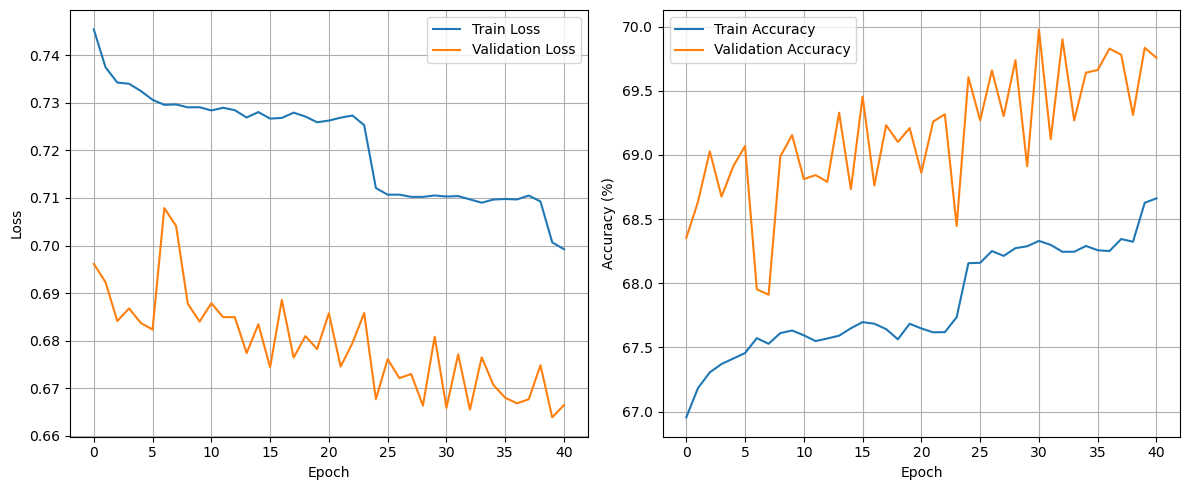

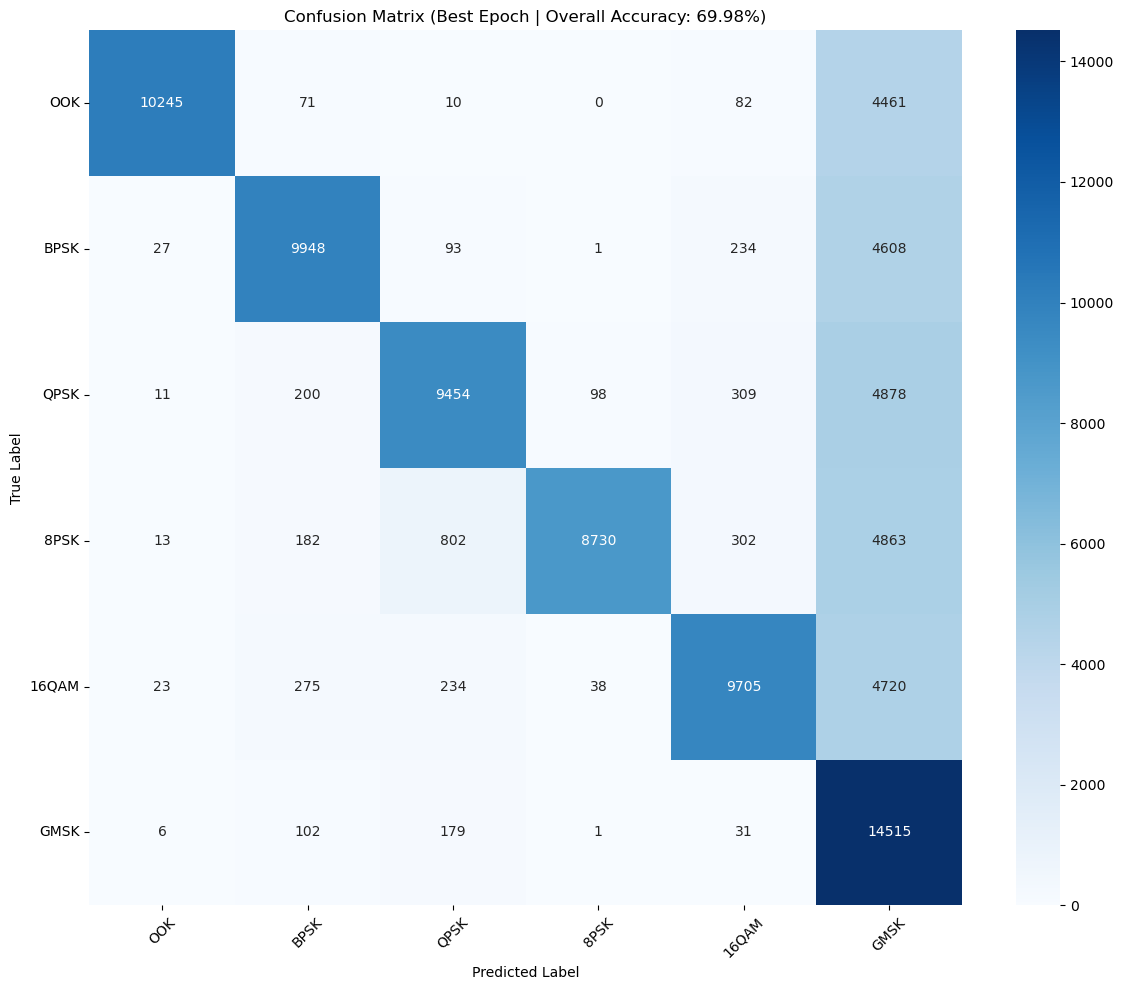

In [57]:
# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    patience=7, 
    factor=0.5,
    verbose=True
)

scaler = GradScaler()

# --- Data Loaders ---
print("\nLoading datasets...")
full_dataset = RadioML18DatasetAugmented('train', use_fft=False,apply_augmentation=True,augmentation_config=get_augmentation_presets()['conservative'])
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
valid_size = dataset_size - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print("Datasets loaded successfully.")
print(f"Total dataset size: {dataset_size}")
print(f"Train dataset size: {len(train_dataset)} (80%)")
print(f"Validation dataset size: {len(valid_dataset)} (20%)")

# --- Training and Validation Loop ---
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
best_accuracy = 0.0
patience_counter = 0
patience = 10
BEST_MODEL_PATH = 'best_cnn_model2.pth'

# Store predictions/labels for confusion matrix
final_predictions = []
final_true_labels = []

print("🚀 Starting Training...")
print("=" * 80)
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<11} {'Valid Loss':<12} {'Valid Acc':<11} {'Time':<8} {'Status'}")
print("=" * 80)

start_time = time.time()  # Track total training time

for epoch in range(NUM_EPOCHS):  # Ensure 'epochs' is defined
    epoch_start = time.time()
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_idx, (inputs, labels, _) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % (len(train_loader) // 4) == 0 and batch_idx > 0:
            progress = (batch_idx / len(train_loader)) * 100
            print(f"\r  Training: {progress:.0f}%", end='', flush=True)
    
    # Validation Phase  
    model.eval()
    valid_loss, valid_correct, valid_total = 0.0, 0, 0
    epoch_predictions = []  # Store current epoch predictions
    epoch_labels = []       # Store current epoch labels
    
    with torch.no_grad():
        for inputs, labels, _ in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()
            
            # Collect for confusion matrix
            epoch_predictions.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_valid_loss = valid_loss / len(valid_loader.dataset)
    epoch_train_acc = 100. * train_correct / train_total
    epoch_valid_acc = 100. * valid_correct / valid_total
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    valid_losses.append(epoch_valid_loss)
    train_accuracies.append(epoch_train_acc)
    valid_accuracies.append(epoch_valid_acc)
    
    # Learning rate scheduling
    scheduler.step(epoch_valid_acc)
    
    # Early stopping check
    if epoch_valid_acc > best_accuracy:
        best_accuracy = epoch_valid_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        # Save best epoch predictions/labels
        final_predictions = epoch_predictions
        final_true_labels = epoch_labels
        status = "💾 BEST"
    else:
        patience_counter += 1
        if patience_counter >= patience:
            status = "⏹️ STOP"
        else:
            status = f"⏳ {patience_counter}/{patience}"
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    
    # Print epoch summary
    print(f"\r{epoch+1:<6} {epoch_train_loss:<12.4f} {epoch_train_acc:<11.2f} {epoch_valid_loss:<12.4f} {epoch_valid_acc:<11.2f} {epoch_time:<8.1f}s {status}")
    
    # Early stopping
    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_time
print("=" * 80)
print(f"✅ Training Complete! Best Accuracy: {best_accuracy:.2f}% | Total Time: {total_time/60:.1f} min")

# --- Plot Training Curves ---
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- Confusion Matrix ---
# Ensure TARGET_MODULATIONS is defined (list of class names)
if len(final_predictions) > 0 and len(final_true_labels) > 0:
    cm = confusion_matrix(final_true_labels, final_predictions)
    accuracy = 100. * np.diag(cm).sum() / cm.sum()

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=TARGET_MODULATIONS, 
                yticklabels=TARGET_MODULATIONS)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix With Signal Augmentation conservative (Best Epoch | Overall Accuracy: {accuracy:.2f}%)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    plt.show()
else:
    print("Warning: No predictions available for confusion matrix")
    

In [ ]:
# --- Loss Function and Optimizer ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=2e-3, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='max', 
    patience=7, 
    factor=0.5,
    verbose=True
)

scaler = GradScaler()

# --- Data Loaders ---
print("\nLoading datasets...")
full_dataset = RadioML18DatasetAugmented('train', use_fft=False,apply_augmentation=True,augmentation_config=get_augmentation_presets()['aggressive'])
dataset_size = len(full_dataset)
train_size = int(0.8 * dataset_size)
valid_size = dataset_size - train_size

train_dataset, valid_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, valid_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
print("Datasets loaded successfully.")
print(f"Total dataset size: {dataset_size}")
print(f"Train dataset size: {len(train_dataset)} (80%)")
print(f"Validation dataset size: {len(valid_dataset)} (20%)")

# --- Training and Validation Loop ---
train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []
best_accuracy = 0.0
patience_counter = 0
patience = 10
BEST_MODEL_PATH = 'best_cnn_model2.pth'

# Store predictions/labels for confusion matrix
final_predictions = []
final_true_labels = []

print("🚀 Starting Training...")
print("=" * 80)
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<11} {'Valid Loss':<12} {'Valid Acc':<11} {'Time':<8} {'Status'}")
print("=" * 80)

start_time = time.time()  # Track total training time

for epoch in range(NUM_EPOCHS):  # Ensure 'epochs' is defined
    epoch_start = time.time()
    
    # Training Phase
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    for batch_idx, (inputs, labels, _) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        with autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        if batch_idx % (len(train_loader) // 4) == 0 and batch_idx > 0:
            progress = (batch_idx / len(train_loader)) * 100
            print(f"\r  Training: {progress:.0f}%", end='', flush=True)
    
    # Validation Phase  
    model.eval()
    valid_loss, valid_correct, valid_total = 0.0, 0, 0
    epoch_predictions = []  # Store current epoch predictions
    epoch_labels = []       # Store current epoch labels
    
    with torch.no_grad():
        for inputs, labels, _ in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            valid_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            valid_total += labels.size(0)
            valid_correct += (predicted == labels).sum().item()
            
            # Collect for confusion matrix
            epoch_predictions.extend(predicted.cpu().numpy())
            epoch_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_valid_loss = valid_loss / len(valid_loader.dataset)
    epoch_train_acc = 100. * train_correct / train_total
    epoch_valid_acc = 100. * valid_correct / valid_total
    
    # Store metrics
    train_losses.append(epoch_train_loss)
    valid_losses.append(epoch_valid_loss)
    train_accuracies.append(epoch_train_acc)
    valid_accuracies.append(epoch_valid_acc)
    
    # Learning rate scheduling
    scheduler.step(epoch_valid_acc)
    
    # Early stopping check
    if epoch_valid_acc > best_accuracy:
        best_accuracy = epoch_valid_acc
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        # Save best epoch predictions/labels
        final_predictions = epoch_predictions
        final_true_labels = epoch_labels
        status = "💾 BEST"
    else:
        patience_counter += 1
        if patience_counter >= patience:
            status = "⏹️ STOP"
        else:
            status = f"⏳ {patience_counter}/{patience}"
    
    # Calculate epoch time
    epoch_time = time.time() - epoch_start
    
    # Print epoch summary
    print(f"\r{epoch+1:<6} {epoch_train_loss:<12.4f} {epoch_train_acc:<11.2f} {epoch_valid_loss:<12.4f} {epoch_valid_acc:<11.2f} {epoch_time:<8.1f}s {status}")
    
    # Early stopping
    if patience_counter >= patience:
        print("Early stopping triggered!")
        break

total_time = time.time() - start_time
print("=" * 80)
print(f"✅ Training Complete! Best Accuracy: {best_accuracy:.2f}% | Total Time: {total_time/60:.1f} min")

# --- Plot Training Curves ---
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# --- Confusion Matrix ---
# Ensure TARGET_MODULATIONS is defined (list of class names)
if len(final_predictions) > 0 and len(final_true_labels) > 0:
    cm = confusion_matrix(final_true_labels, final_predictions)
    accuracy = 100. * np.diag(cm).sum() / cm.sum()

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=TARGET_MODULATIONS, 
                yticklabels=TARGET_MODULATIONS)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix With Signal Augmentation Aggressive (Best Epoch | Overall Accuracy: {accuracy:.2f}%)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('best_confusion_matrix.png')
    plt.show()
else:
    print("Warning: No predictions available for confusion matrix")
    

/tmp/ipykernel_67367/299165429.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Loading datasets...
Dataset 'train' configured with Signal Augmentation.
🔧 Applying I/Q swap fix to train dataset...
✅ I/Q channels corrected for real-world compatibility for train dataset.
Datasets loaded successfully.
Total dataset size: 447252
Train dataset size: 357801 (80%)
Validation dataset size: 89451 (20%)
🚀 Starting Training...
Epoch  Train Loss   Train Acc   Valid Loss   Valid Acc   Time     Status


/tmp/ipykernel_67367/299165429.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


1      0.7918       65.43       0.7091       68.26       148.7   s 💾 BEST
2      0.7836       65.58       0.7146       67.97       150.1   s ⏳ 1/10
3      0.7825       65.75       0.7170       67.76       150.3   s ⏳ 2/10
4      0.7792       65.73       0.7199       67.36       148.8   s ⏳ 3/10
5      0.7794       65.78       0.7061       68.04       148.8   s ⏳ 4/10
6      0.7764       65.80       0.7108       67.75       150.3   s ⏳ 5/10
7      0.7774       65.86       0.7057       68.07       148.2   s ⏳ 6/10
8      0.7765       65.78       0.7124       67.86       150.6   s ⏳ 7/10
9      0.7746       65.86       0.7182       67.72       150.7   s ⏳ 8/10
10     0.7576       66.43       0.6929       68.77       150.2   s 💾 BEST
11     0.7590       66.50       0.7073       67.97       147.8   s ⏳ 1/10
12     0.7563       66.59       0.6914       68.76       146.9   s ⏳ 2/10
13     0.7575       66.54       0.6975       68.46       149.2   s ⏳ 3/10
14     0.7565       66.58       0.6975